In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from warnings import filterwarnings

from scipy.sparse import csr_matrix, issparse
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from pyclustering.cluster.birch import birch as pyclustering_birch
from pyclustering.cluster.dbscan import dbscan as pyclustering_dbscan
from pyclustering.cluster.clique import clique as pyclustering_clique

from enum import Enum
from typing import Any, cast

filterwarnings("ignore")

In [3]:
class ModelNames(str, Enum):
    KMEANS = "K-Means (Baseline)"
    AGGLOMERATIVE = "Agglomerative"
    BIRCH = "BIRCH"
    DBSCAN = "DBSCAN"
    CLIQUE = "CLIQUE"

class EVALUATION_VARIATIONS(int, Enum):
    NO_PCA_NO_LEGTH_FILTER = 1
    NO_PCA_WITH_LENGTH_FILTER = 2
    PCA_NO_LENGTH_FILTER = 3
    PCA_WITH_LENGTH_FILTER = 4

MODEL_LIST: list[ModelNames] = list(ModelNames)

CURRENT_DIR: str = os.path.dirname(os.path.abspath("__file__"))
ALL_SEQUENCES_DATASET_PATH: str = os.path.join(CURRENT_DIR, 'data', "all_sequences.csv")
COMPLETE_SEQUENCES_DATASET_PATH: str = os.path.join(CURRENT_DIR, 'data', "complete_sequences.csv")

RANDOM_STATE: int = 34234
VARIANCE_LEVELS: list[float] = [0.05, 0.10, 0.15]
MAX_REDUCTION_COMPONENTS: int = 50
TOP_N_FEATURES: int = 15
TOP_K_REPEATS: int = 30

DATASET_PATHS: dict[str, str] = {
    "All Sequences": ALL_SEQUENCES_DATASET_PATH,
    "Complete Sequences": COMPLETE_SEQUENCES_DATASET_PATH,
}

FIGURES_DIR = os.path.join(CURRENT_DIR, "images")
os.makedirs(FIGURES_DIR, exist_ok=True)

In [4]:
def map_repeat_lengths(df: pd.DataFrame) -> dict[int, int]:
    """Maps repeat lengths to the count of repeats having that length.

    Args:
        df (pd.DataFrame): Input DataFrame whose repeats are evaluated.

    Returns:
        dict[int, int]: Dictionary with repeat length as key and count as value.
    """
    length_counts: dict[int, int] = {}
    for repeat_name in df.columns:
        name_length: int = len(str(repeat_name))
        length_counts[name_length] = length_counts.get(name_length, 0) + 1

    return length_counts

In [5]:
def plot_repeat_length_distribution(
    length_counts: dict[int, int],
    dataset_name: str
) -> None:
    """Plots a bar chart displaying the frequency distribution of repeat lengths in the dataset.

    Args:
        length_counts (dict[int, int]): Dictionary mapping repeat lengths to their counts.
        dataset_name (str): Name of the dataset for labeling the plot.
        
    Returns:
        None
    """
    lengths: list[int] = list(length_counts.keys())
    counts: list[int] = list(length_counts.values())

    plt.figure(figsize=(10, 6))
    plt.bar(lengths, counts, color="skyblue", edgecolor="black")
    plt.xlabel("Repeat Length")
    plt.ylabel("Count")
    plt.xticks(lengths)
    plt.title(f"Distribution of Repeat Lengths in {dataset_name}")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

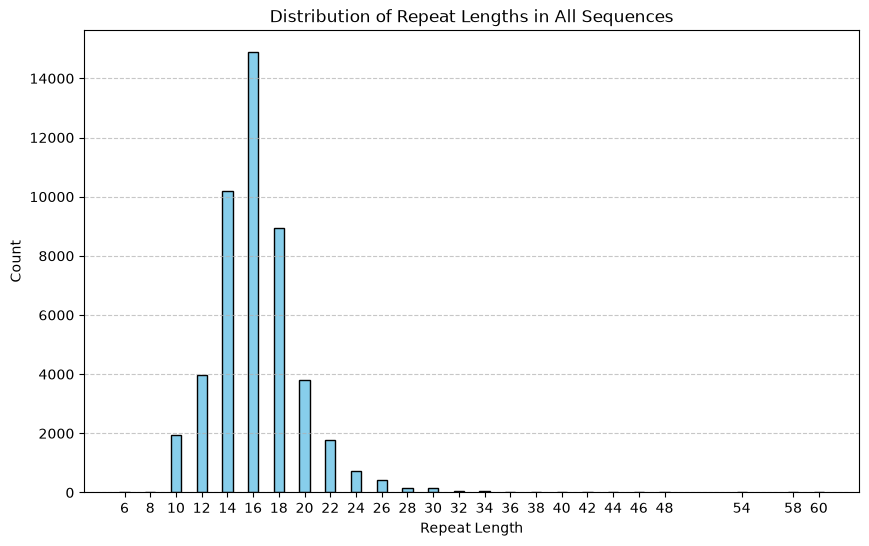

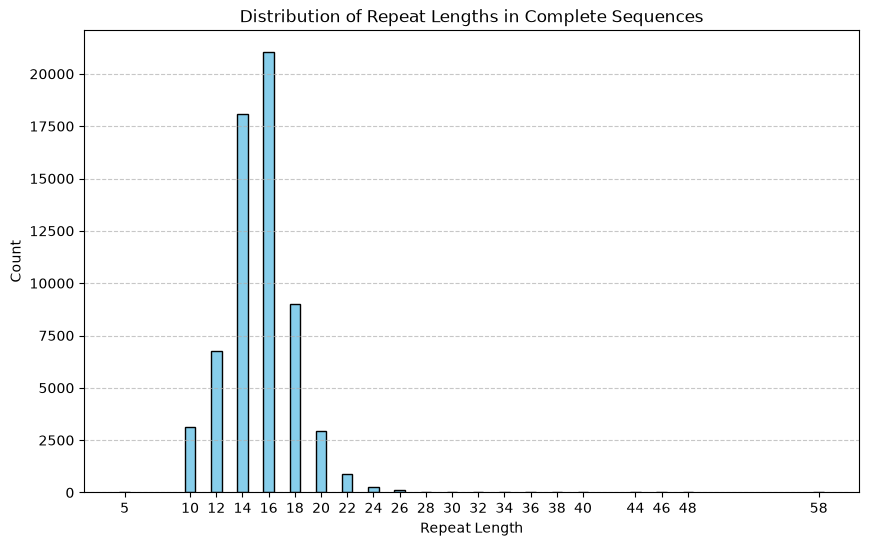

In [6]:
for dataset_name, dataset_path in DATASET_PATHS.items():
    df: pd.DataFrame = pd.read_csv(dataset_path)
    repeat_length_counts: dict[int, int] = map_repeat_lengths(df)
    sorted_repeat_length_counts: dict[int, int] = dict(sorted(repeat_length_counts.items(), key=lambda x: x[0]))
    plot_repeat_length_distribution(length_counts=sorted_repeat_length_counts, dataset_name=dataset_name)

The most frequent repeats for the "All Sequences" dataset are those with lengths 12, 14, 16, 18 and 20.
To reduce the number of repeats, only the specified lengths will be kept in the dataset.
<br>
The most frequent repeats for the "Complete Sequences" dataset are those with lengths 10, 12, 14, 16, 18 and 20.
Same logic will be applied to this dataset as well, keeping only the specified lengths.

In [7]:
TARGET_REPEAT_LENGTHS: dict[str, list[int]] = {
    "All Sequences": [12, 14, 16, 18, 20],
    "Complete Sequences": [10, 12, 14, 16, 18, 20],
}

def filter_repeats_by_length(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Filters the repeats in the DataFrame by their length.

    Args:
        df (pd.DataFrame): The input DataFrame containing repeat columns.
        dataset_name (str): The name of the dataset, used to determine target lengths.
        
    Returns:
        pd.DataFrame: A new DataFrame containing only columns with target lengths.
    """
    valid_columns: list[str] = [col for col in df.columns if len(str(col)) in TARGET_REPEAT_LENGTHS[dataset_name]]
    filtered_df: pd.DataFrame = df[valid_columns].copy()
    return filtered_df

In [8]:
def tfidf_transform(df: pd.DataFrame) -> np.ndarray[Any]:
    """Apply TF-IDF transformation to the binary matrix representation of the dataset.

    Args:
        df (pd.DataFrame): The input DataFrame containing the binary matrix.

    Returns:
        np.ndarray[Any]: The TF-IDF transformed sparse matrix.
    """
    binary_matrix: csr_matrix = csr_matrix(df.values)

    tfidf: TfidfTransformer = TfidfTransformer(
        use_idf=True,
        smooth_idf=True,
        norm="l2"
    )

    return tfidf.fit_transform(binary_matrix)

In [9]:
def calculate_metrics(
    X: Any, 
    labels: np.ndarray, 
    metric: str = "euclidean"
) -> dict[str, float] | None:
    """Evaluate the clustering results using Silhouette score, Calinski-Harabasz score, and Davies-Bouldin score.

    Args:
        X (np.ndarray): The input (dimensionality-reduced) matrix.
        labels (np.ndarray): The cluster labels assigned to each sample.
        metric (str): The distance metric used for the Silhouette score. Defaults to "euclidean",

    Returns:
        dict[str, float] | None: A dictionary containing the evaluation scores for Silhouette, Calinski-Harabasz, and Davies-Bouldin.
    """
    labels = np.asarray(labels)
    n_clusters: int = len(set(labels))

    if n_clusters < 2:
        return None
    if n_clusters >= len(labels):
        return None

    X_adjusted: np.ndarray = X.toarray() if issparse(X) or hasattr(X, "toarray") else X

    return {
        "silhouette": float(silhouette_score(X_adjusted, labels, metric=metric)),
        "calinski_harabasz": calinski_harabasz_score(X_adjusted, labels),
        "davies_bouldin": davies_bouldin_score(X_adjusted, labels)
    }

In [10]:
def reduce_with_pca(X: np.ndarray[Any], max_components: int = MAX_REDUCTION_COMPONENTS) -> tuple[np.ndarray, PCA]:
    """Fit a single PCA model (sparse-compatible `arpack` solver) with as many components as feasible.

    Because PCA components are nested (the first k components of a PCA fit with
    m > k components are identical to a PCA fit with exactly k components), a
    single fit can be sliced afterwards to obtain the smallest number of
    components that reach any target explained-variance ratio.

    Args:
        X (np.ndarray[Any]): The TF-IDF transformed (sparse) input matrix.
        max_components (int): Upper bound on the number of components to fit.

    Returns:
        tuple[np.ndarray, PCA]: The fully transformed matrix and the fitted PCA instance.
    """
    n_components: int = min(max_components, X.shape[0] - 1, X.shape[1] - 1)
    pca: PCA = PCA(n_components=n_components, svd_solver="arpack", random_state=RANDOM_STATE)
    X_full: np.ndarray[Any] = pca.fit_transform(X)
    return X_full, pca

In [11]:
def components_for_variance(reducer: PCA, target_variance: float) -> int:
    """Return the smallest number of components whose cumulative explained variance ratio reaches `target_variance`.

    Args:
        reducer (PCA): A fitted PCA instance.
        target_variance (float): The desired cumulative explained variance ratio (e.g. 0.05 for 5%).

    Returns:
        int: The number of components to keep.
    """
    cumulative_variance: np.ndarray[Any] = reducer.explained_variance_ratio_.cumsum()
    idx: np.intp = np.searchsorted(cumulative_variance, target_variance)
    return int(min(idx + 1, len(cumulative_variance)))

In [12]:
def labels_from_pyclustering(clusters: list[Any], n_samples: int) -> np.ndarray:
    """Convert `pyclustering`'s clusters/noise index lists into a sklearn-style label array.

    Args:
        clusters (list[list[int]]): A list of clusters, each a list of sample indices.
        n_samples (int): Total number of samples.

    Returns:
        np.ndarray: An array of cluster labels of length `n_samples`.
    """
    labels: np.ndarray[Any] = np.full(n_samples, -1, dtype=int)
    for cluster_id, indices in enumerate(clusters):
        labels[indices] = cluster_id
    return labels

In [13]:
def estimate_eps_candidates(
    X: np.ndarray[Any],
    k: int = 5, 
    percentiles: tuple[int, ...] = (25, 50, 75)
) -> list[float]:
    """Estimate a small set of DBSCAN `eps` candidates from the k-th nearest neighbor distance distribution.

    This is the standard DBSCAN "elbow" heuristic: candidate `eps` values are
    taken from percentiles of each point's distance to its k-th nearest
    neighbor, which adapts automatically to the scale of each reduced dataset.

    Args:
        X (np.ndarray[Any]): The input data.
        k (int): Which nearest neighbor's distance to use.
        percentiles (tuple[int, ...]): Percentiles of the k-th neighbor distance distribution to use as candidates.

    Returns:
        list[float]: A sorted list of candidate `eps` values.
    """
    n_neighbors: int = min(k, X.shape[0] - 1)
    if n_neighbors < 1:
        return [1e-3]

    distances, _ = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(X).kneighbors(X)
    kth_distances: np.ndarray[Any] = distances[:, -1]
    candidates: list[float] = sorted({float(np.percentile(kth_distances, p)) for p in percentiles})
    return [c for c in candidates if c > 0] or [1e-3]

In [14]:
def fit_predict(model_name: ModelNames, X: np.ndarray, params: dict[str, Any]) -> np.ndarray:
    """Fit the given clustering model on X with the given hyperparameters and return predicted labels.

    Args:
        model_name (ModelNames): Which clustering algorithm to run.
        X (np.ndarray): The (dimensionality-reduced) input data.
        params (dict[str, Any]): Hyperparameters to construct the model with.

    Returns:
        np.ndarray: Predicted cluster labels (-1 marks noise for the density-based models).
    """
    if model_name == ModelNames.KMEANS:
        return KMeans(**params).fit_predict(X)

    if model_name == ModelNames.AGGLOMERATIVE:
        return AgglomerativeClustering(**params).fit_predict(X)

    data: list[Any] = X.tolist()

    if model_name == ModelNames.BIRCH:
        instance: Any = pyclustering_birch(data, **params)
        instance.process()
        clusters: list[Any] = instance.get_clusters()
        return labels_from_pyclustering(clusters=clusters, n_samples=len(data))

    if model_name == ModelNames.DBSCAN:
        instance = pyclustering_dbscan(data, **params)
        instance.process()
        clusters_dbscan = cast(list[list[int]], instance.get_clusters())
        return labels_from_pyclustering(clusters=clusters_dbscan, n_samples=len(data))

    if model_name == ModelNames.CLIQUE:
        instance = pyclustering_clique(data, **params)
        instance.process()
        clusters = list(instance.get_clusters())
        return labels_from_pyclustering(clusters=clusters, n_samples=len(data))

    raise ValueError(f"Unsupported model: {model_name}")

In [15]:
def get_param_grid(model_name: ModelNames, X: np.ndarray) -> dict[str, list[Any]]:
    """Return the hyperparameter grid to search for the given model.

    `X` is only used to derive data-dependent values (the number of clusters
    must stay below the sample count, and DBSCAN's `eps` is estimated from X).

    Args:
        model_name (ModelNames): Which clustering algorithm the grid is for.
        X (np.ndarray): The (dimensionality-reduced) input data.

    Returns:
        dict[str, list[Any]]: A mapping of hyperparameter name to candidate values.
    """
    n_samples: int = X.shape[0]
    cluster_options: list[int] = [k for k in (2, 3, 4, 6, 8) if k < n_samples]

    if model_name == ModelNames.KMEANS:
        return {
            "n_clusters": cluster_options,
            "init": ["k-means++"],
            "n_init": [10],
            "max_iter": [300],
            "random_state": [RANDOM_STATE],
        }

    if model_name == ModelNames.AGGLOMERATIVE:
        return {
            "n_clusters": cluster_options,
            "linkage": ["ward", "average", "complete"],
            "metric": ["euclidean", "cosine"],
        }

    if model_name == ModelNames.BIRCH:
        return {
            "number_clusters": cluster_options,
            "diameter": [0.1, 0.3, 0.5],
        }

    if model_name == ModelNames.DBSCAN:
        return {
            "eps": estimate_eps_candidates(X),
            "neighbors": [3, 5, 10],
        }

    if model_name == ModelNames.CLIQUE:
        # Kept intentionally small: CLIQUE's grid-cell count grows as amount_intervals ** n_dimensions
        return {
            "amount_intervals": [3, 4],
            "density_threshold": [1, 2],
        }

    raise ValueError(f"Unsupported model: {model_name}")

In [16]:
def find_cluster_repeats(
    df_binary: pd.DataFrame,
    labels: np.ndarray[Any],
    top_k: int = 30,
    min_prevalence: float = 0.01,
) -> dict[int, pd.DataFrame]:
    """Find repeats that are most characteristic for each cluster.

    Repeats are ranked according to the difference between their prevalence inside the cluster and their global prevalence.

    Args:
        df_binary (pd.DataFrame): Original binary repeat matrix. Rows are genomes and columns are repeats.
        labels (np.ndarray[Any]): Cluster labels for each genome. A label of -1 is treated as noise and excluded from the analysis.
        top_k (int): Number of characteristic repeats to return per cluster.
        min_prevalence (float): Minimum prevalence of a repeat inside a cluster required for consideration.

    Returns:
        dict[int, pd.DataFrame]: A dictionary mapping each cluster label to a DataFrame containing its most characteristic repeats.
    """
    labels = np.asarray(labels)
    valid_mask: np.ndarray[Any] = labels != -1

    df: pd.DataFrame = df_binary.loc[valid_mask].copy()
    cluster_labels: np.ndarray[Any] = labels[valid_mask]

    df = (df > 0).astype(np.int8)
    clusters: list[int] = sorted(np.unique(cluster_labels))
    results: dict[int, pd.DataFrame] = {}
    global_prevalence: pd.Series = df.mean(axis=0)

    for cluster_id in clusters:
        cluster_mask: np.ndarray[Any] = cluster_labels == cluster_id
        cluster_df: pd.DataFrame = df.loc[cluster_mask]

        cluster_prevalence: pd.Series = cluster_df.mean(axis=0)
        prevalence_difference: pd.Series = (
            cluster_prevalence - global_prevalence
        )

        candidate_mask: pd.Series = cluster_prevalence >= min_prevalence
        candidate_columns = df.columns[candidate_mask]

        cluster_results = pd.DataFrame({
            "repeat": candidate_columns,
            "cluster_prevalence": (
                cluster_prevalence[candidate_columns].values
            ),
            "global_prevalence": (
                global_prevalence[candidate_columns].values
            ),
            "prevalence_difference": (
                prevalence_difference[candidate_columns].values
            ),
        })
        cluster_results = cluster_results.sort_values(
            by="prevalence_difference",
            ascending=False,
        )

        results[cluster_id] = (
            cluster_results
            .head(top_k)
            .reset_index(drop=True)
        )

    return results

In [17]:
def grid_search(
    model_name: ModelNames,
    X: np.ndarray[Any],
) -> tuple[
    dict[str, float] | None,
    dict[str, Any],
    np.ndarray[Any] | None,
]:
    """Run an exhaustive grid search and return the best clustering result.

    The configuration with the highest Silhouette score is selected.

    Args:
        model_name (ModelNames): Which clustering algorithm to search over.
        X (np.ndarray): The dimensionality-reduced input data.

    Returns:
        tuple:
            - Best clustering scores, or None if no valid configuration exists.
            - Hyperparameters of the best configuration.
            - Cluster labels produced by the best configuration, or None.
    """
    param_grid: dict[str, list[Any]] = get_param_grid(
        model_name=model_name,
        X=X,
    )

    best_silhouette: float = -1.0
    best_scores: dict[str, float] | None = None
    best_params: dict[str, Any] = {}
    best_labels: np.ndarray[Any] | None = None

    for values in product(*param_grid.values()):
        params: dict[str, Any] = dict(
            zip(param_grid.keys(), values)
        )

        try:
            labels: np.ndarray[Any] = fit_predict(
                model_name=model_name,
                X=X,
                params=params,
            )
        except Exception:
            continue

        scores: dict[str, float] | None = calculate_metrics(
            X=X,
            labels=labels,
        )

        if scores is None:
            continue

        if scores["silhouette"] > best_silhouette:
            best_silhouette = scores["silhouette"]
            best_scores = scores
            best_params = params
            best_labels = labels.copy()

    return best_scores, best_params, best_labels

In [18]:
def append_clustering_results_pca(
    results: list[dict[str, Any]],
    reduction_cache: dict[str, tuple[np.ndarray, PCA]],
    dataset_name: str,
    X: np.ndarray[Any],
    df_binary: pd.DataFrame,
    variance_levels: list[float] = VARIANCE_LEVELS,
    top_k_repeats: int = 30,
) -> list[dict[str, Any]]:
    """Append clustering results for all models and PCA variance levels.

    For every variance level, the best configuration of each clustering
    algorithm is selected according to Silhouette score. The repeats that
    best characterize each resulting cluster are then determined from the
    original binary repeat matrix.

    Args:
        results (list[dict[str, Any]]): The list to append results to.
        reduction_cache (dict[str, tuple[np.ndarray, PCA]]): Cache of reduced
            data and fitted PCA instances.
        dataset_name (str): Name of the dataset.
        X (np.ndarray): TF-IDF transformed input data.
        df_binary (pd.DataFrame): Original binary repeat matrix.
        variance_levels (list[float]): PCA explained variance levels.
        top_k_repeats (int): Number of characteristic repeats to keep per
            cluster.

    Returns:
        list[dict[str, Any]]: Updated list of clustering results.
    """
    X_full, reducer = reduce_with_pca(X=X)

    reduction_cache[dataset_name] = (
        X_full,
        reducer,
    )

    for variance_level in variance_levels:
        n_components: int = components_for_variance(
            reducer=reducer,
            target_variance=variance_level,
        )

        X_reduced: np.ndarray[Any] = X_full[:, :n_components]

        for model_name in MODEL_LIST:
            scores, params, labels = grid_search(
                model_name=model_name,
                X=X_reduced,
            )

            if scores is None or labels is None:
                print(
                    f"[{dataset_name} | PCA | "
                    f"{variance_level:.0%} var] "
                    f"{model_name.value}: "
                    f"no valid configuration found"
                )
                continue

            cluster_repeats: dict[int, pd.DataFrame] = (
                find_cluster_repeats(
                    df_binary=df_binary,
                    labels=labels,
                    top_k=top_k_repeats,
                )
            )

            results.append({
                "dataset": dataset_name,
                "variance_level": variance_level,
                "n_components": n_components,
                "cluster_repeats": cluster_repeats,
                "model": model_name.value,
                **scores,
                "params": params,
            })

            print(
                f"[{dataset_name} | PCA | "
                f"{variance_level:.0%} var, "
                f"n_components={n_components}] "
                f"{model_name.value}: "
                f"silhouette={scores['silhouette']:.4f}"
            )

    return results

In [19]:
def append_clustering_results_no_pca(
    results: list[dict[str, Any]],
    dataset_name: str,
    X: np.ndarray[Any],
 ) -> list[dict[str, Any]]:
    """Append clustering results for all models without PCA to the results list.

    Args:
        results (list[dict[str, Any]]): The list to append results to.
        dataset_name (str): Name of the dataset.
        X (np.ndarray[Any]): The TF-IDF transformed input data.

    Returns:
        list[dict[str, Any]]: The updated list of results.
    """
    for model_name in MODEL_LIST:
        scores, params, labels = grid_search(model_name=model_name, X=X)
        if scores is None or labels is None:
            print(f"[{dataset_name}] {model_name.value}: no valid configuration found")
            continue

        results.append({
            "dataset": dataset_name,
            "model": model_name.value,
            **scores,
            "params": params,
        })

        print(f"[{dataset_name}] {model_name.value}: silhouette={scores['silhouette']:.4f}")

    return results

In [20]:
def evaluate_clustering(
    use_pca: bool = True,
    drop_columns_by_length: bool = True,
    variance_levels: list[float] = VARIANCE_LEVELS,
) -> pd.DataFrame:
    """Evaluate clustering performance on all datasets.

    Args:
        use_pca (bool): Whether PCA should be used for dimensionality
            reduction.
        drop_columns_by_length (bool): Whether repeats should be filtered
            according to their lengths.
        variance_levels (list[float]): PCA explained variance levels to test.

    Returns:
        pd.DataFrame: DataFrame containing clustering results.
    """
    results: list[dict[str, Any]] = []
    reduction_cache: dict[str, tuple[np.ndarray, PCA]] = {}

    print(
        f"Is PCA enabled: {use_pca}, "
        f"Drop columns by length: {drop_columns_by_length}"
    )
    print("-" * 80)

    for dataset_name, dataset_path in DATASET_PATHS.items():
        df: pd.DataFrame = pd.read_csv(dataset_path)

        if drop_columns_by_length:
            df = filter_repeats_by_length(
                df=df,
                dataset_name=dataset_name,
            )

        X_binary: pd.DataFrame = df.copy()
        X_tfidf: np.ndarray[Any] = tfidf_transform(df)

        if use_pca:
            append_clustering_results_pca(
                results=results,
                reduction_cache=reduction_cache,
                dataset_name=dataset_name,
                X=X_tfidf,
                df_binary=X_binary,
                variance_levels=variance_levels,
                top_k_repeats=TOP_K_REPEATS,
            )
        else:
            append_clustering_results_no_pca(
                results=results,
                dataset_name=dataset_name,
                X=X_tfidf,
            )

        print("\n\n")

    return pd.DataFrame(results)

## Evaluation with and without PCA

In [21]:
results_dict: dict[EVALUATION_VARIATIONS, pd.DataFrame] = {
    EVALUATION_VARIATIONS.NO_PCA_NO_LEGTH_FILTER: evaluate_clustering(
        use_pca=False, 
        drop_columns_by_length=False, 
        variance_levels=VARIANCE_LEVELS
    ),
    EVALUATION_VARIATIONS.NO_PCA_WITH_LENGTH_FILTER: evaluate_clustering(
        use_pca=False, 
        drop_columns_by_length=True, 
        variance_levels=VARIANCE_LEVELS
    ),
    EVALUATION_VARIATIONS.PCA_NO_LENGTH_FILTER: evaluate_clustering(
        use_pca=True, 
        drop_columns_by_length=False, 
        variance_levels=VARIANCE_LEVELS
    ),
    EVALUATION_VARIATIONS.PCA_WITH_LENGTH_FILTER: evaluate_clustering(
        use_pca=True, 
        drop_columns_by_length=True, 
        variance_levels=VARIANCE_LEVELS
    ),
}

Is PCA enabled: False, Drop columns by length: False
--------------------------------------------------------------------------------
[All Sequences] K-Means (Baseline): silhouette=0.0571
[All Sequences] Agglomerative: no valid configuration found
[All Sequences] BIRCH: no valid configuration found
[All Sequences] DBSCAN: no valid configuration found
[All Sequences] CLIQUE: no valid configuration found



[Complete Sequences] K-Means (Baseline): silhouette=0.1196
[Complete Sequences] Agglomerative: no valid configuration found
[Complete Sequences] BIRCH: no valid configuration found
[Complete Sequences] DBSCAN: no valid configuration found
[Complete Sequences] CLIQUE: no valid configuration found



Is PCA enabled: False, Drop columns by length: True
--------------------------------------------------------------------------------
[All Sequences] K-Means (Baseline): silhouette=0.0832
[All Sequences] Agglomerative: no valid configuration found
[All Sequences] BIRCH: no valid configuratio

Based on the validation results, dimensionality reduction is key to improving evaluation metrics. To further analyze this effect, PCA will be implemented with higher cumulative variance ratios to compare performance against the previously tested 5%, 10%, and 15% thresholds.

In [ ]:
ADDITIONAL_VARIANCE_LEVELS: list[float] = [0.2, 0.4, 0.6]

results_dict_new: dict[EVALUATION_VARIATIONS, pd.DataFrame] = {
    EVALUATION_VARIATIONS.PCA_NO_LENGTH_FILTER: evaluate_clustering(
        use_pca=True, 
        drop_columns_by_length=False, 
        variance_levels=ADDITIONAL_VARIANCE_LEVELS
    ),
    EVALUATION_VARIATIONS.PCA_WITH_LENGTH_FILTER: evaluate_clustering(
        use_pca=True, 
        drop_columns_by_length=True, 
        variance_levels=ADDITIONAL_VARIANCE_LEVELS
    ),
}

Is PCA enabled: True, Drop columns by length: False
--------------------------------------------------------------------------------
[All Sequences | PCA | 20% var, n_components=15] K-Means (Baseline): silhouette=0.4893
[All Sequences | PCA | 20% var, n_components=15] Agglomerative: silhouette=0.5297
[All Sequences | PCA | 20% var, n_components=15] BIRCH: silhouette=0.5268
[All Sequences | PCA | 20% var, n_components=15] DBSCAN: silhouette=0.0861
[All Sequences | PCA | 20% var, n_components=15] CLIQUE: silhouette=-0.1360
[All Sequences | PCA | 40% var, n_components=50] K-Means (Baseline): silhouette=0.3019
[All Sequences | PCA | 40% var, n_components=50] Agglomerative: silhouette=0.3363
[All Sequences | PCA | 40% var, n_components=50] BIRCH: silhouette=0.3287
[All Sequences | PCA | 40% var, n_components=50] DBSCAN: silhouette=0.2055
[All Sequences | PCA | 40% var] CLIQUE: no valid configuration found
[All Sequences | PCA | 60% var, n_components=50] K-Means (Baseline): silhouette=0.3019

As results show, increasing the cumulative variance ratio doesn't yield to higher metric results. <br>
Another dimensionality reduction approach is to evaluate the models on the top N most frequent repeats 

## Dimensionality reduction by keeping the top N most frequent repeats

In [30]:
def filter_repeats_by_frequency(df: pd.DataFrame, top_n: int = TOP_N_FEATURES) -> pd.DataFrame:
    """Filters the repeats in the DataFrame by their frequency.

    Args:
        df (pd.DataFrame): The input DataFrame containing repeat columns.
        top_n (int): The number of top features to keep based on frequency.

    Returns:
        pd.DataFrame: A new DataFrame containing only the top N most frequent columns.
    """
    repeat_frequency_percent: pd.Series = (
        (df > 0).sum(axis=0) / len(df) * 100
    )
    repeat_frequency_percent = repeat_frequency_percent.sort_values(ascending=False)
    top_repeats: pd.Index = repeat_frequency_percent.head(top_n).index
    return df[top_repeats].copy()

In [ ]:
def evaluate_clustering_by_feature_frequency(
    use_pca: bool = True,
    top_n: int = TOP_N_FEATURES,
) -> pd.DataFrame:
    """Evaluate clustering performance on all datasets preprocessed by feature frequency.
    If PCA is used, the 0.95 explained variance ratio is used for dimensionality reduction.

    Args:
        use_pca (bool): True if PCA should be used for dimensionality reduction, False otherwise.
        top_n (int): The number of top features to keep based on frequency. Default is TOP_N_FEATURES.

    Returns:
        pd.DataFrame: A DataFrame containing clustering results for all datasets.
    """
    results: list[dict[str, Any]] = []
    reduction_cache: dict[str, tuple[np.ndarray, PCA]] = {}

    print(f"Is PCA enabled: {use_pca}")
    print("-"*80)

    for dataset_name, dataset_path in DATASET_PATHS.items():
        df: pd.DataFrame = pd.read_csv(dataset_path)

        df = filter_repeats_by_frequency(df=df, top_n=top_n)

        X_binary: pd.DataFrame = df.copy()
        X_tfidf: np.ndarray[Any] = tfidf_transform(df)

        if use_pca:
            append_clustering_results_pca(
                results=results,
                reduction_cache=reduction_cache,
                dataset_name=dataset_name,
                X=X_tfidf,
                df_binary=X_binary,
                variance_levels=[0.95],
                top_k_repeats=TOP_K_REPEATS,
            )
        else:
            append_clustering_results_no_pca(
                results=results,
                dataset_name=dataset_name,
                X=X_tfidf,
            )

        print("\n\n")

    return pd.DataFrame(results)

In [35]:
TOP_N_MOST_FREQUENT_FEATURES: list[int] = [50, 100, 200]

results_dict_frequency: dict[int, dict[EVALUATION_VARIATIONS, pd.DataFrame]] = {}

for n in TOP_N_MOST_FREQUENT_FEATURES:
    print(f"Evaluating clustering with top {n} most frequent features")
    print("#"*80, "\n")
    results_dict_frequency[n] = {
        EVALUATION_VARIATIONS.NO_PCA_NO_LEGTH_FILTER: evaluate_clustering_by_feature_frequency(
            use_pca=False,
            top_n=n
        ),
        EVALUATION_VARIATIONS.PCA_NO_LENGTH_FILTER: evaluate_clustering_by_feature_frequency(
            use_pca=True,
            top_n=n
        ),
    }
    print("\n\n")

Evaluating clustering with top 50 most frequent features
################################################################################ 

Is PCA enabled: False
--------------------------------------------------------------------------------
[All Sequences] K-Means (Baseline): silhouette=0.1795
[All Sequences] Agglomerative: no valid configuration found
[All Sequences] BIRCH: no valid configuration found
[All Sequences] DBSCAN: no valid configuration found
[All Sequences] CLIQUE: no valid configuration found



[Complete Sequences] K-Means (Baseline): silhouette=0.2779
[Complete Sequences] Agglomerative: no valid configuration found
[Complete Sequences] BIRCH: no valid configuration found
[Complete Sequences] DBSCAN: no valid configuration found
[Complete Sequences] CLIQUE: no valid configuration found



Is PCA enabled: True
--------------------------------------------------------------------------------
[All Sequences | PCA | 95% var, n_components=32] K-Means (Baseline): silhouette=

## Optimal evaluation variation results

For both datasets, the optimal results are achieved when applying the PCA and keeping the 5 % variance, with length filter. <br>
The most important repeats within the determined clusters are shown below.

In [ ]:
optimal_results_df: pd.DataFrame = results_dict[EVALUATION_VARIATIONS.PCA_WITH_LENGTH_FILTER].where(
    results_dict[EVALUATION_VARIATIONS.PCA_WITH_LENGTH_FILTER]["variance_level"] == 0.05
).dropna()

In [30]:
pd.set_option("display.max_colwidth", 100)

optimal_results_df

,dataset,variance_level,n_components,cluster_repeats,model,silhouette,calinski_harabasz,davies_bouldin,params
0,All Sequences,0.05,3.0,"{0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...",K-Means (Baseline),0.782882,2750.663689,0.225581,"{'n_clusters': 2, 'init': 'k-means++', 'n_init': 10, 'max_iter': 300, 'random_state': 34234}"
1,All Sequences,0.05,3.0,"{0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...",Agglomerative,0.794962,3906.826348,0.205371,"{'n_clusters': 3, 'linkage': 'average', 'metric': 'euclidean'}"
2,All Sequences,0.05,3.0,"{0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...",BIRCH,0.797408,3908.636237,0.180952,"{'number_clusters': 3, 'diameter': 0.3}"
3,All Sequences,0.05,3.0,"{0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...",DBSCAN,0.002534,103.114976,2.775744,"{'eps': 0.0030876377336695603, 'neighbors': 3}"
4,All Sequences,0.05,3.0,"{0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference']}",CLIQUE,0.344013,1.695474,2.080290,"{'amount_intervals': 4, 'density_threshold': 1}"
15,Complete Sequences,0.05,1.0,"{0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...",K-Means (Baseline),0.779473,1214.073997,0.311846,"{'n_clusters': 2, 'init': 'k-means++', 'n_init': 10, 'max_iter': 300, 'random_state': 34234}"
16,Complete Sequences,0.05,1.0,"{0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...",Agglomerative,0.779473,1214.073997,0.311846,"{'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}"
17,Complete Sequences,0.05,1.0,"{0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...",BIRCH,0.779473,1214.073997,0.311846,"{'number_clusters': 2, 'diameter': 0.1}"
18,Complete Sequences,0.05,1.0,"{0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...",DBSCAN,0.455589,94.087283,3.451267,"{'eps': 0.005027842678457128, 'neighbors': 3}"


In [31]:
optimal_results_df["cluster_repeats"]

0     {0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...
1     {0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...
2     {0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...
3     {0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...
4                     {0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference']}
15    {0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...
16    {0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...
17    {0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...
18    {0: ['repeat', 'cluster_prevalence', 'global_prevalence', 'prevalence_difference'], 1: ['repeat'...
Name: cluster_repeats, dtype: object

### All Sequences dataset - top 30 repeats with the highest cluster prevalence <br><br>
Repeats are ranked according to the difference between their prevalence inside the cluster and their global prevalence. <br>
Cluster prevalence is calculated as the mean presence of each repeat across all genomes belonging to a specific cluster, representing the proportion of genomes in that cluster that contain the repeat.


In [45]:
kmeans_cp_all: pd.DataFrame = optimal_results_df["cluster_repeats"][0][0]
agglomerative_cp_all: pd.DataFrame = optimal_results_df["cluster_repeats"][1][0]
birch_cp_all: pd.DataFrame = optimal_results_df["cluster_repeats"][2][0]

In [46]:
kmeans_cp_all

,repeat,cluster_prevalence,global_prevalence,prevalence_difference
0,AAAGAAAAGAAA,0.246723,0.241710,0.005013
1,AAGAAAAAAGAA,0.237505,0.232680,0.004826
2,AGAAGAAGAAGA,0.236497,0.231692,0.004805
3,AAGGAAAAGGAA,0.231312,0.226612,0.004700
4,TATTATTATTAT,0.218493,0.214054,0.004440
5,AAAAAAAAAAAA,0.216045,0.211655,0.004390
6,GAAAAGGAAAAG,0.192136,0.188232,0.003904
7,AGAAAAAAAAGA,0.191128,0.187244,0.003884
8,ACAAAAAAAACA,0.185799,0.182023,0.003775
9,AAAGAAAAAAGAAA,0.185655,0.181882,0.003772


In [47]:
agglomerative_cp_all

,repeat,cluster_prevalence,global_prevalence,prevalence_difference
0,AAAGAAAAGAAA,0.251394,0.241710,0.009684
1,AAGAAAAAAGAA,0.242002,0.232680,0.009322
2,AGAAGAAGAAGA,0.240974,0.231692,0.009283
3,AAGGAAAAGGAA,0.235691,0.226612,0.009079
4,TATTATTATTAT,0.222630,0.214054,0.008576
5,AAAAAAAAAAAA,0.220135,0.211655,0.008480
6,GAAAAGGAAAAG,0.195773,0.188232,0.007541
7,AGAAAAAAAAGA,0.194746,0.187244,0.007502
8,ACAAAAAAAACA,0.189316,0.182023,0.007293
9,AAAGAAAAAAGAAA,0.189169,0.181882,0.007287


In [48]:
birch_cp_all

,repeat,cluster_prevalence,global_prevalence,prevalence_difference
0,AAAGAAAAGAAA,0.251173,0.241710,0.009463
1,AAGAAAAAAGAA,0.241789,0.232680,0.009109
2,AGAAGAAGAAGA,0.240762,0.231692,0.009071
3,AAGGAAAAGGAA,0.235484,0.226612,0.008872
4,TATTATTATTAT,0.222434,0.214054,0.008380
5,AAAAAAAAAAAA,0.219941,0.211655,0.008286
6,GAAAAGGAAAAG,0.195601,0.188232,0.007369
7,AGAAAAAAAAGA,0.194575,0.187244,0.007331
8,ACAAAAAAAACA,0.189150,0.182023,0.007126
9,AAAGAAAAAAGAAA,0.189003,0.181882,0.007121


### Complete Sequences - top 30 repeats with the highest cluster prevalence

In [50]:
kmeans_cp_complete: pd.DataFrame = optimal_results_df["cluster_repeats"][0][1]
agglomerative_cp_complete: pd.DataFrame = optimal_results_df["cluster_repeats"][1][1]
birch_cp_complete: pd.DataFrame = optimal_results_df["cluster_repeats"][2][1]

In [51]:
kmeans_cp_complete

,repeat,cluster_prevalence,global_prevalence,prevalence_difference
0,GTATTTTTTATG,0.993056,0.076337,0.916719
1,TTTATGGTATTT,0.993056,0.088190,0.904866
2,ACGTATTTTATGCA,0.888889,0.022577,0.866312
3,TTTTTTTTTTTT,0.097222,0.217299,-0.120077


In [52]:
agglomerative_cp_complete

,repeat,cluster_prevalence,global_prevalence,prevalence_difference
0,ATATAACCAATATA,1.000,0.024270,0.975730
1,AAAAGGCCGGAAAA,1.000,0.025258,0.974742
2,AGTGTCAACTGTGA,1.000,0.025822,0.974178
3,TAATGAGGAGTAAT,1.000,0.026386,0.973614
4,CACTACAACATCAC,1.000,0.027233,0.972767
5,GTTTATGGTATTTG,1.000,0.028503,0.971497
6,GACGTTAATTGCAG,1.000,0.031466,0.968534
7,GAGGACAACAGGAG,1.000,0.032172,0.967828
8,CATGAACCAAGTAC,1.000,0.032736,0.967264
9,ACGACCAACCAGCA,0.984,0.017356,0.966644


In [53]:
birch_cp_complete

,repeat,cluster_prevalence,global_prevalence,prevalence_difference
0,GTATTTTTTATG,0.992958,0.076337,0.916621
1,TTTATGGTATTT,0.992958,0.088190,0.904768
2,ACGTATTTTATGCA,0.901408,0.022577,0.878832
3,TTTTTTTTTTTT,0.084507,0.217299,-0.132792
